# Notebook 3 — Figures (country-level)

Three separate saved figures:
- **Panel A** `figures/panel_A.png` — growth rate choropleth by country
- **Panel B** `figures/panel_B.png` — country share by subfield (stacked bar)
- **Panel C** `figures/panel_C.png` — side-by-side co-authorship networks

**Input:** `data/papers.csv`, `data/country_subfield_pivot.csv`,
`data/network_2001_2010.graphml`, `data/network_2011_2025.graphml`

In [1]:
# !pip install geopandas matplotlib networkx pandas pyarrow scipy

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
import urllib.request, zipfile, io

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import networkx as nx
import numpy as np
import pandas as pd

def find_project_root():
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for parent in [start] + list(start.parents):
        if (parent / 'data' / 'papers.csv').exists():
            return parent
    return Path.cwd()

ROOT    = find_project_root()
DATA    = ROOT / 'data'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

TOP_SUBFIELDS   = ['Computer Science', 'Physics', 'Mathematics',
                   'High Energy Physics', 'Astrophysics', 'Statistics']
COMPARE_PERIODS = ['2001-2010', '2011-2025']

COUNTRY_COLORS = {
    'United States of America': '#1565C0',
    'China':         '#C62828',
    'United Kingdom':'#2E7D32',
    'Germany':       '#6A1B9A',
    'France':        '#00838F',
    'Japan':         '#E65100',
    'Russia':        '#4E342E',
    'Canada':        '#0277BD',
    'Italy':         '#558B2F',
    'South Korea':   '#AD1457',
    'Switzerland':   '#F9A825',
    'India':         '#FF8F00',
    'Taiwan':        '#00695C',
    'Spain':         '#D84315',
    'Netherlands':   '#283593',
    'Sweden':        '#00796B',
    'Brazil':        '#1B5E20',
    'Australia':     '#4527A0',
    'Israel':        '#1A237E',
    'Iran':          '#827717',
    'Poland':        '#880E4F',
    'Austria':       '#37474F',
    'Singapore':     '#006064',
    'Argentina':     '#33691E',
    'Mexico':        '#BF360C',
    'Turkey':        '#4A148C',
    'South Africa':  '#212121',
    'Egypt':         '#795548',
    'Saudi Arabia':  '#F57F17',
}
def get_country_color(c): return COUNTRY_COLORS.get(c, '#BDBDBD')

print(f'Project root : {ROOT}')
print(f'papers.csv   : {(DATA / "papers.csv").exists()}')
print(f'pivot.csv    : {(DATA / "country_subfield_pivot.csv").exists()}')
print(f'net 2001-2010: {(DATA / "network_2001_2010.graphml").exists()}')
print(f'net 2011-2025: {(DATA / "network_2011_2025.graphml").exists()}')
print('Imports OK.')


Project root : /Users/lipengyao/Documents/DataMining/final
papers.csv   : True
pivot.csv    : True
net 2001-2010: True
net 2011-2025: True
Imports OK.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────
papers = pd.read_csv(DATA / 'papers.csv')
papers['year'] = pd.to_numeric(papers['year'], errors='coerce').fillna(0).astype(int)
pivot  = pd.read_csv(DATA / 'country_subfield_pivot.csv')

print(f'Papers  : {len(papers):,}')
print(f'Pivot   : {pivot.shape}')
print(f'Country coverage: {(papers["country"] != "Unknown").mean():.1%}')
print('Top countries:')
print(papers[papers['country'] != 'Unknown']['country'].value_counts().head(10))


Papers  : 2,872,364
Pivot   : (398, 4)
Country coverage: 11.0%
Top countries:
country
United States of America    133238
Australia                    37586
France                       32976
Italy                        17032
United Kingdom               14853
Germany                      13864
Singapore                    12937
Iran                         11985
China                         8767
Japan                         5490
Name: count, dtype: int64


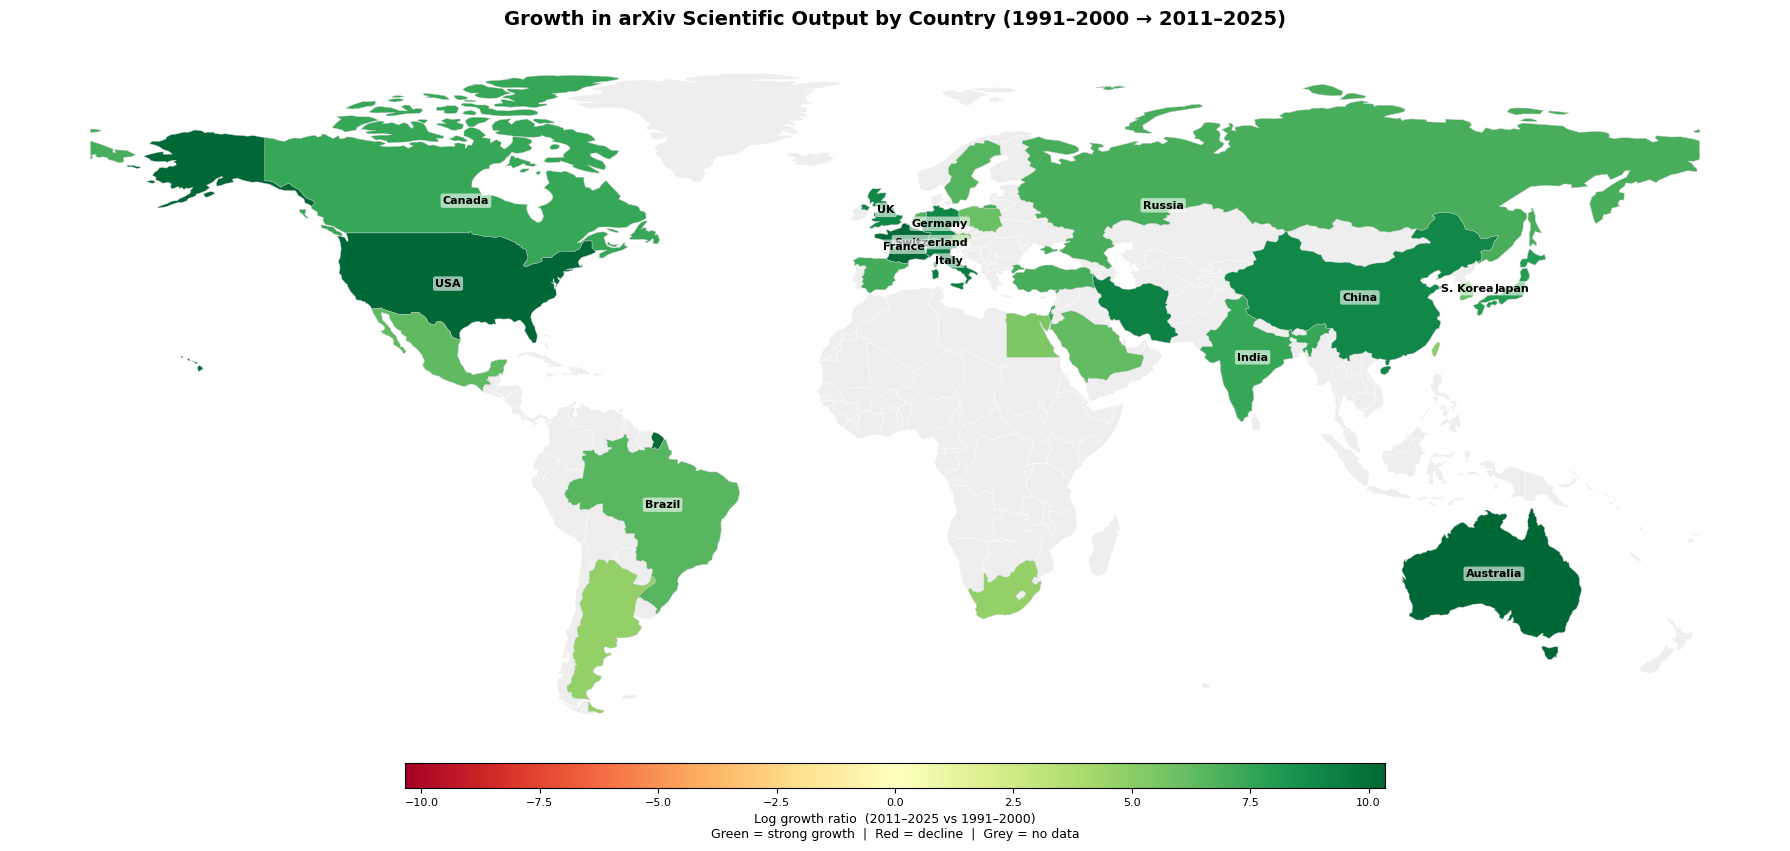

Panel A saved → /Users/lipengyao/Documents/DataMining/final/figures/panel_A.png


In [3]:
# ── PANEL A: Growth rate choropleth (country level) ──────────────────
# Load Natural Earth shapefile
NE_DIR = DATA / 'ne_110m_admin_0_countries'
if not NE_DIR.exists():
    print('Downloading Natural Earth...')
    url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
    with urllib.request.urlopen(url) as r:
        with zipfile.ZipFile(io.BytesIO(r.read())) as z:
            z.extractall(str(NE_DIR))
shp   = next(NE_DIR.glob('*.shp'))
world = gpd.read_file(shp)
name_col = 'NAME' if 'NAME' in world.columns else 'ADMIN'
world = world.rename(columns={name_col: 'name'})
world = world[world['name'] != 'Antarctica'].copy()

# Count papers per country per period directly from papers['country']
early_counts  = papers[(papers['year'] >= 1991) & (papers['year'] <= 2000)]['country'].value_counts().to_dict()
recent_counts = papers[(papers['year'] >= 2011) & (papers['year'] <= 2025)]['country'].value_counts().to_dict()

world['count_early']  = world['name'].map(early_counts).fillna(0)
world['count_recent'] = world['name'].map(recent_counts).fillna(0)
world['log_growth']   = np.log1p(world['count_recent']) - np.log1p(world['count_early'])
world.loc[(world['count_early'] == 0) & (world['count_recent'] == 0), 'log_growth'] = np.nan

fig, ax = plt.subplots(figsize=(18, 9), facecolor='white')
world.plot(color='#EEEEEE', linewidth=0.3, edgecolor='white', ax=ax)

vabs = world['log_growth'].abs().quantile(0.95)
norm = mcolors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
cmap = plt.get_cmap('RdYlGn')
world.dropna(subset=['log_growth']).plot(
    column='log_growth', cmap=cmap, norm=norm,
    linewidth=0.3, edgecolor='#CCCCCC', ax=ax, legend=False,
)

LABEL_XY = {
    'United States of America': ((-100, 38), 'USA'),
    'China':         (( 104, 35), 'China'),
    'United Kingdom':(( -2,  54), 'UK'),
    'Germany':       ((  10, 51), 'Germany'),
    'Japan':         (( 138, 37), 'Japan'),
    'India':         ((  80, 22), 'India'),
    'South Korea':   (( 128, 37), 'S. Korea'),
    'Brazil':        (( -52,-10), 'Brazil'),
    'Russia':        ((  60, 55), 'Russia'),
    'Switzerland':   ((   8, 47), 'Switzerland'),
    'Australia':     (( 134,-25), 'Australia'),
    'France':        ((   2, 46), 'France'),
    'Italy':         ((  12, 43), 'Italy'),
    'Canada':        (( -96, 56), 'Canada'),
}
wd = world.dropna(subset=['log_growth'])
for country, ((cx, cy), label) in LABEL_XY.items():
    if len(wd[wd['name'] == country]) == 0: continue
    ax.annotate(label, xy=(cx, cy), fontsize=8, ha='center', va='center',
                fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.6))

sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, aspect=40)
cbar.set_label('Log growth ratio  (2011–2025 vs 1991–2000)\nGreen = strong growth  |  Red = decline  |  Grey = no data', fontsize=9)
cbar.ax.tick_params(labelsize=8)
ax.set_axis_off()
ax.set_title('Growth in arXiv Scientific Output by Country (1991–2000 → 2011–2025)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
out_a = FIG_DIR / 'panel_A.png'
plt.savefig(out_a, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Panel A saved → {out_a}')


Top 8 countries: ['United States of America', 'Australia', 'France', 'Italy', 'United Kingdom', 'Germany', 'Singapore', 'Iran']


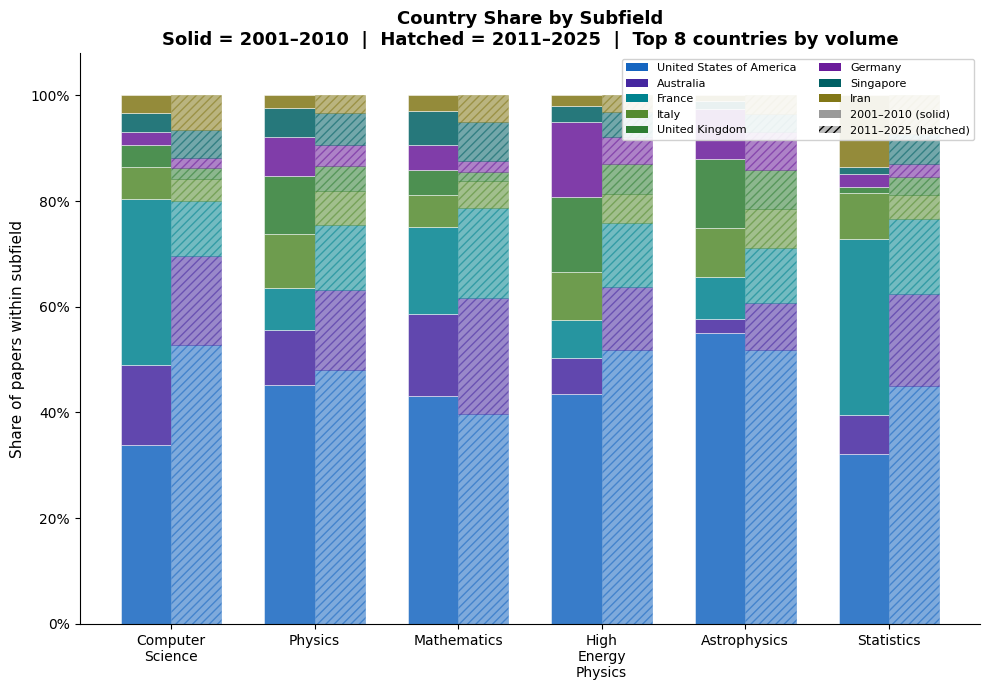

Panel B saved → /Users/lipengyao/Documents/DataMining/final/figures/panel_B.png


In [4]:
# ── PANEL B: Country share by subfield (stacked bar) ─────────────────
GEO_COL = 'country' if 'country' in pivot.columns else 'region'

# Auto-select top 8 countries by total paper count
TOP_COUNTRIES = (
    pivot[pivot[GEO_COL] != 'Unknown']
    .groupby(GEO_COL)['paper_count'].sum()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)
print('Top 8 countries:', TOP_COUNTRIES)

bump = pivot[
    pivot['subfield'].isin(TOP_SUBFIELDS) &
    pivot[GEO_COL].isin(TOP_COUNTRIES)
].copy()
total = bump.groupby(['period','subfield'])['paper_count'].transform('sum')
bump['share'] = bump['paper_count'] / total

bar_data = {}
for period in COMPARE_PERIODS:
    sub = bump[bump['period'] == period]
    pt  = sub.pivot_table(index='subfield', columns=GEO_COL, values='share', fill_value=0)
    pt  = pt.reindex(index=TOP_SUBFIELDS, columns=TOP_COUNTRIES, fill_value=0)
    bar_data[period] = pt

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
x, bar_w = np.arange(len(TOP_SUBFIELDS)), 0.35
offsets  = [-bar_w/2, bar_w/2]
hatches  = ['', '////']

for p_idx, (period, hatch) in enumerate(zip(COMPARE_PERIODS, hatches)):
    bottoms = np.zeros(len(TOP_SUBFIELDS))
    for country in TOP_COUNTRIES:
        vals = bar_data[period][country].values
        ax.bar(x + offsets[p_idx], vals, bar_w, bottom=bottoms,
               color=get_country_color(country),
               alpha=0.85 if hatch == '' else 0.55,
               hatch=hatch,
               edgecolor='white' if hatch == '' else get_country_color(country),
               linewidth=0.4)
        bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels([sf.replace(' ','\n') for sf in TOP_SUBFIELDS], fontsize=10)
ax.set_ylabel('Share of papers within subfield', fontsize=11)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.spines[['top','right']].set_visible(False)
ax.set_title(
    'Country Share by Subfield\n'
    'Solid = 2001–2010  |  Hatched = 2011–2025  |  Top 8 countries by volume',
    fontsize=13, fontweight='bold'
)
country_handles = [mpatches.Patch(facecolor=get_country_color(c), label=c) for c in TOP_COUNTRIES]
period_handles  = [
    mpatches.Patch(facecolor='#888888', alpha=0.85, label='2001–2010 (solid)'),
    mpatches.Patch(facecolor='#888888', alpha=0.55, hatch='////', label='2011–2025 (hatched)'),
]
ax.legend(handles=country_handles + period_handles,
          fontsize=8, loc='upper right', framealpha=0.9, ncol=2)
plt.tight_layout()
out_b = FIG_DIR / 'panel_B.png'
plt.savefig(out_b, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Panel B saved → {out_b}')


2001-2010 : 42,954 nodes, 164,523 edges
2011-2025 : 66,502 nodes, 283,935 edges
Union: 1,190 nodes — computing layout...
Layout done.


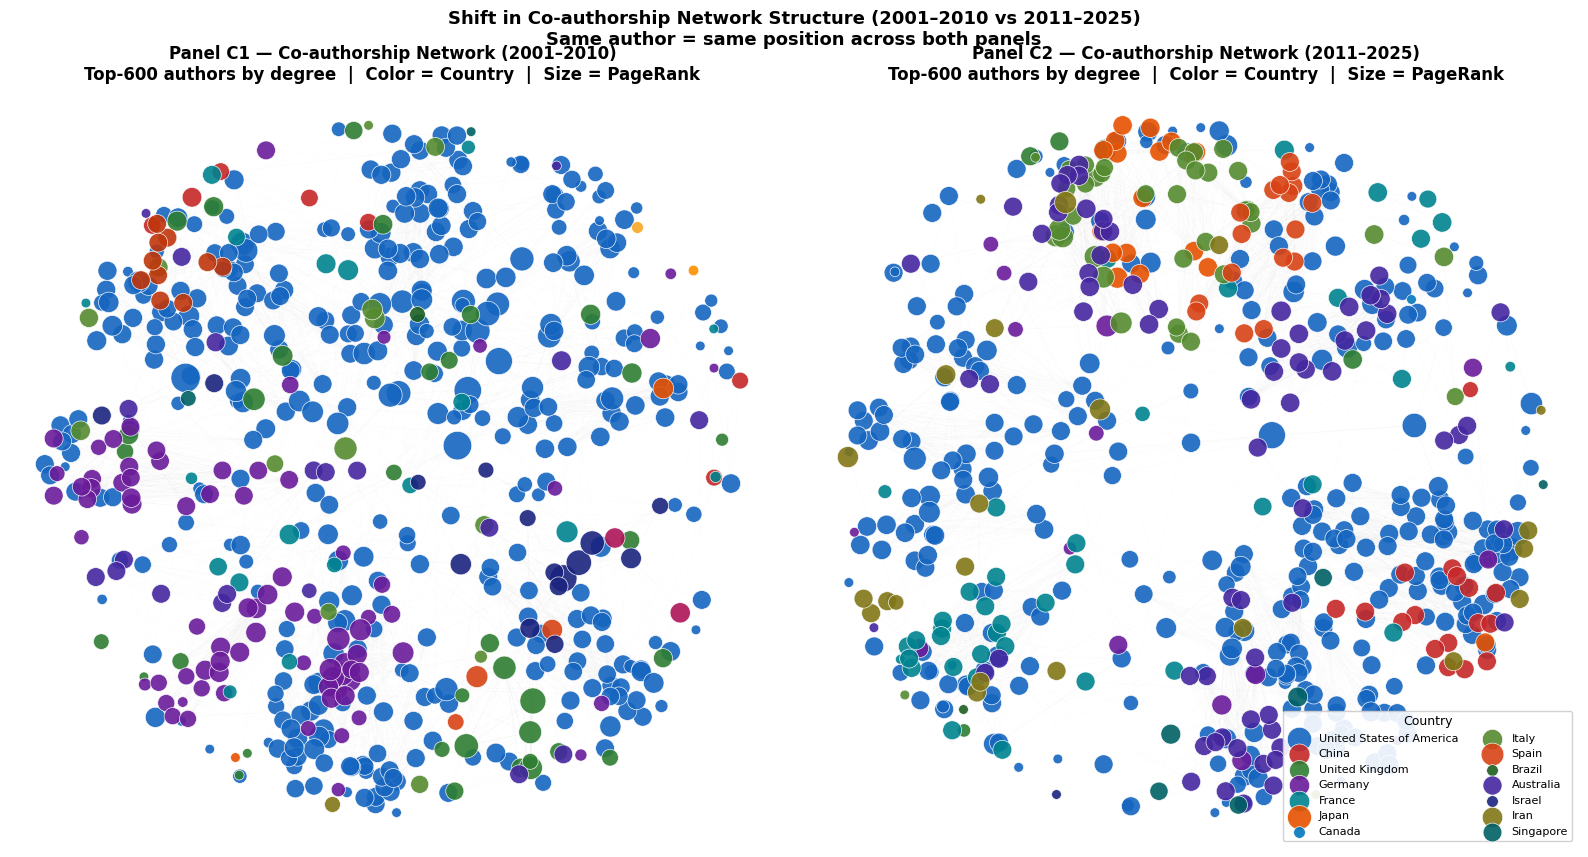

Panel C saved → /Users/lipengyao/Documents/DataMining/final/figures/panel_C.png


In [5]:
# ── PANEL C: Side-by-side co-authorship networks (2001-2010 vs 2011-2025)
G_mid    = nx.read_graphml(str(DATA / 'network_2001_2010.graphml'))
G_recent = nx.read_graphml(str(DATA / 'network_2011_2025.graphml'))
print(f'2001-2010 : {G_mid.number_of_nodes():,} nodes, {G_mid.number_of_edges():,} edges')
print(f'2011-2025 : {G_recent.number_of_nodes():,} nodes, {G_recent.number_of_edges():,} edges')

def top_known_nodes(G, n=600):
    """Top-n nodes by degree where country is known."""
    known = [nd for nd, d in G.nodes(data=True) if d.get('country','Unknown') != 'Unknown']
    G_k   = G.subgraph(known).copy()
    top   = [nd for nd, _ in sorted(G_k.degree, key=lambda x: x[1], reverse=True)[:n]]
    return G_k.subgraph(top).copy()

G_mid_plot    = top_known_nodes(G_mid,    n=600)
G_recent_plot = top_known_nodes(G_recent, n=600)

# Shared layout from union graph so same authors sit at same position
G_union = nx.Graph()
G_union.add_nodes_from(G_mid_plot.nodes(data=True))
G_union.add_nodes_from(G_recent_plot.nodes(data=True))
for u, v, d in list(G_mid_plot.edges(data=True)) + list(G_recent_plot.edges(data=True)):
    if G_union.has_edge(u, v):
        G_union[u][v]['weight'] = G_union[u][v].get('weight',1) + d.get('weight',1)
    else:
        G_union.add_edge(u, v, weight=d.get('weight',1))
print(f'Union: {G_union.number_of_nodes():,} nodes — computing layout...')
shared_pos = nx.spring_layout(G_union, seed=42, k=0.5, iterations=80)
print('Layout done.')

pr_mid        = nx.pagerank(G_mid_plot,    weight='weight')
pr_recent     = nx.pagerank(G_recent_plot, weight='weight')
pr_global_max = max(max(pr_mid.values()), max(pr_recent.values()))

def draw_network(ax, G, pr, title):
    nodes = list(G.nodes)
    # Edges
    ew = np.array([G[u][v].get('weight',1) for u,v in G.edges])
    if len(ew):
        wn = (ew - ew.min()) / (ew.max() - ew.min() + 1e-9)
        for (u,v), w in zip(G.edges, wn):
            if u not in shared_pos or v not in shared_pos: continue
            x0,y0 = shared_pos[u]; x1,y1 = shared_pos[v]
            ax.plot([x0,x1],[y0,y1], color='#CCCCCC',
                    alpha=0.05+0.18*w, linewidth=0.4, zorder=1)
    # Nodes — sized by PageRank, colored by country
    pr_arr  = np.array([pr.get(n,0) for n in nodes])
    pr_norm = pr_arr / (pr_global_max + 1e-9)
    sizes   = 25 + pr_norm * 420
    valid   = [n for n in nodes if n in shared_pos]
    xs = np.array([shared_pos[n][0] for n in valid])
    ys = np.array([shared_pos[n][1] for n in valid])

    for country, color in COUNTRY_COLORS.items():
        idx = np.array([i for i,n in enumerate(valid)
                        if G.nodes[n].get('country') == country])
        if len(idx) == 0: continue
        ax.scatter(xs[idx], ys[idx], c=color, s=sizes[idx],
                   alpha=0.9, zorder=3, linewidths=0.5,
                   edgecolors='white', label=country)
    ax.set_axis_off()
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 9), facecolor='white')
fig.subplots_adjust(wspace=0.05, left=0.01, right=0.99, top=0.88, bottom=0.04)

draw_network(ax_l, G_mid_plot,    pr_mid,
             'Panel C1 — Co-authorship Network (2001–2010)\n'
             'Top-600 authors by degree  |  Color = Country  |  Size = PageRank')
draw_network(ax_r, G_recent_plot, pr_recent,
             'Panel C2 — Co-authorship Network (2011–2025)\n'
             'Top-600 authors by degree  |  Color = Country  |  Size = PageRank')

# Deduplicated legend on right panel
handles, labels = ax_r.get_legend_handles_labels()
seen = {}; dedup_h, dedup_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True; dedup_h.append(h); dedup_l.append(l)
ax_r.legend(dedup_h, dedup_l, fontsize=8, loc='lower right',
            framealpha=0.9, markerscale=1.2, scatterpoints=1,
            title='Country', title_fontsize=9, ncol=2)

fig.suptitle(
    'Shift in Co-authorship Network Structure (2001–2010 vs 2011–2025)\n'
    'Same author = same position across both panels',
    fontsize=13, fontweight='bold', y=0.97
)
out_c = FIG_DIR / 'panel_C.png'
plt.savefig(out_c, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Panel C saved → {out_c}')
